In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score,
    classification_report, confusion_matrix
)
import xgboost as xgb

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')   # clean plot style

print("✅ All imports done")

✅ All imports done


In [12]:
df = pd.read_csv('corporate_ai_adoption_dataset.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print()
print(df.head())
print()
print("Missing values:")
print(df.isnull().sum())

Shape: (200000, 13)
Columns: ['company_id', 'industry', 'country', 'year', 'ai_adoption_level', 'ai_investment_usd', 'automation_rate', 'cost_savings', 'revenue_impact', 'productivity_gain', 'employee_ai_training_hours', 'ai_maturity_score', 'deployment_count']

   company_id            industry        country  year  ai_adoption_level  \
0  CORP-06613  Financial Services          China  2029             0.4987   
1  CORP-01597         Agriculture        Germany  2032             0.5213   
2  CORP-02938              Energy  United States  2024             0.6147   
3  CORP-05207              Retail        Germany  2021             0.4401   
4  CORP-07489          Technology  United States  2024             0.1918   

   ai_investment_usd  automation_rate  cost_savings  revenue_impact  \
0           11747237           0.4119       3519354         2751513   
1            1267219           0.4580        295244          304776   
2            8168951           0.5821       2472329         5

In [13]:
df = df.dropna(subset=['ai_maturity_score', 'ai_adoption_level'])
print(f"Shape after dropping NaN rows: {df.shape}")
print()
print(df.describe().round(2))

Shape after dropping NaN rows: (200000, 13)

            year  ai_adoption_level  ai_investment_usd  automation_rate  \
count  200000.00          200000.00          200000.00        200000.00   
mean     2024.99               0.53         4870558.44             0.44   
std         6.05               0.26         3679703.77             0.22   
min      2015.00               0.01           47888.00             0.00   
25%      2020.00               0.33         2221252.25             0.27   
50%      2025.00               0.53         3991639.50             0.43   
75%      2030.00               0.72         6517931.25             0.59   
max      2035.00               1.00        54170345.00             0.95   

       cost_savings  revenue_impact  productivity_gain  \
count     200000.00    2.000000e+05          200000.00   
mean     2128917.87    2.591989e+06               0.40   
std      2415688.90    3.972751e+06               0.20   
min         4649.00   -1.437676e+07            

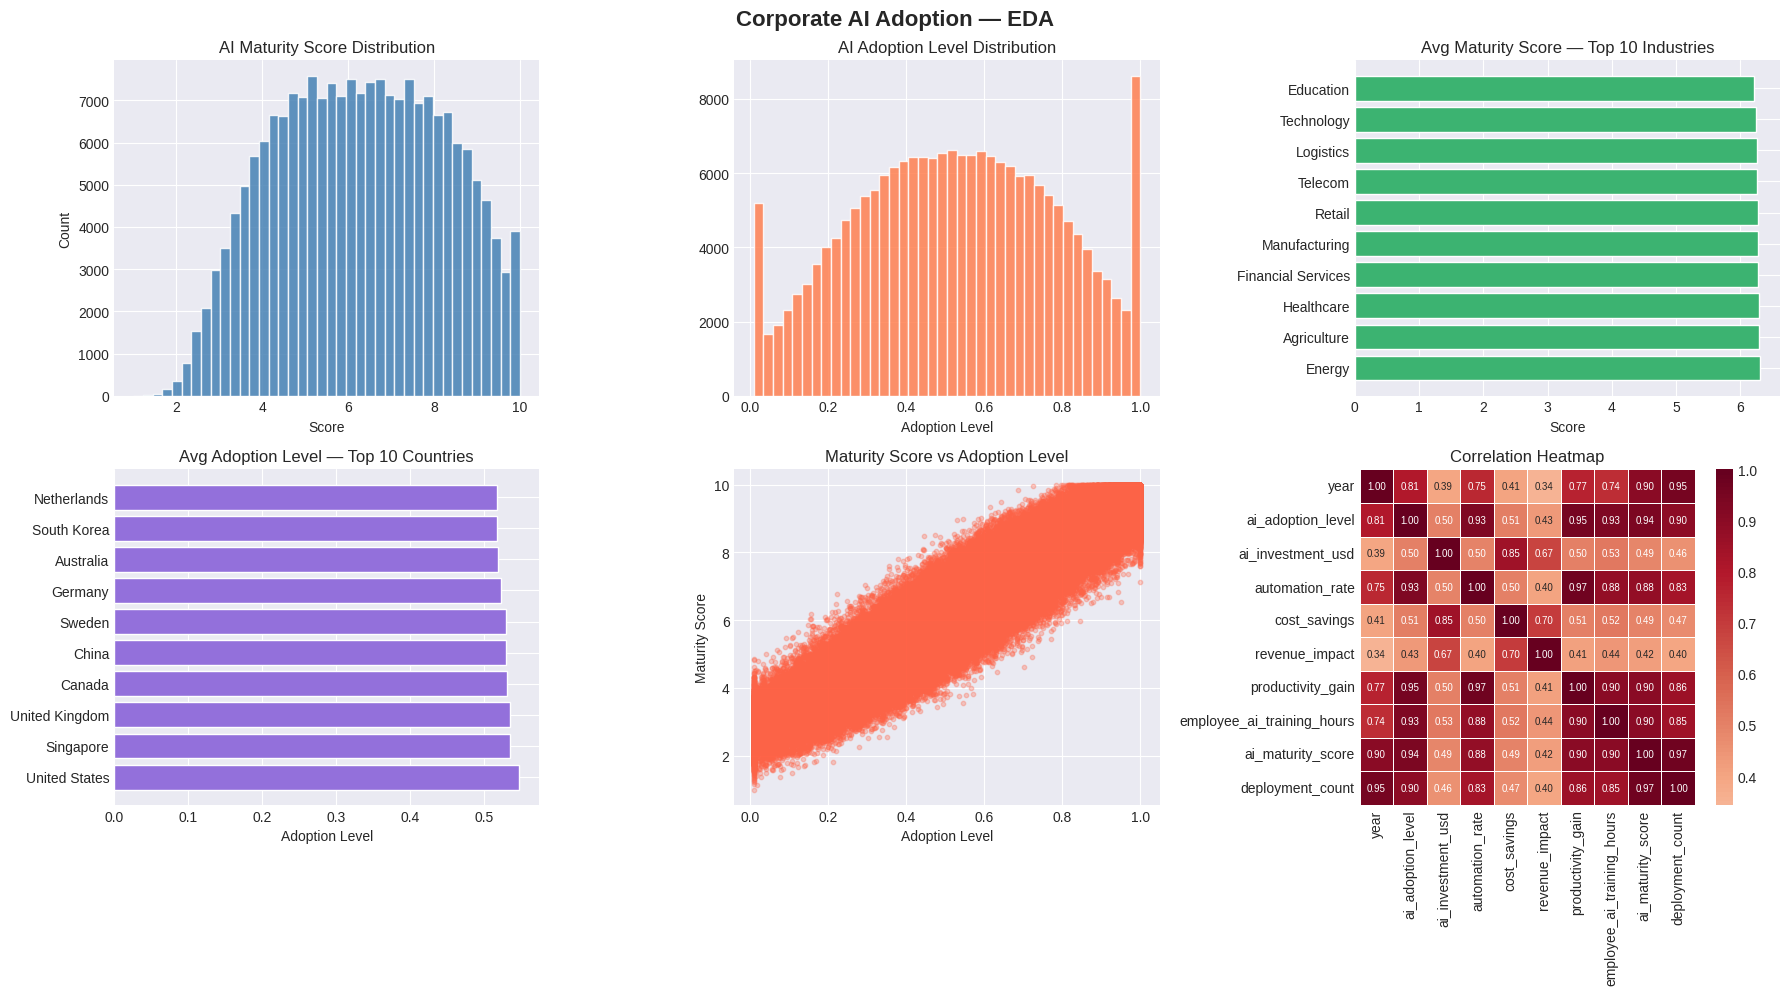

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Corporate AI Adoption — EDA', fontsize=16, fontweight='bold')

# 1. Target: ai_maturity_score distribution
axes[0, 0].hist(df['ai_maturity_score'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('AI Maturity Score Distribution')
axes[0, 0].set_xlabel('Score'); axes[0, 0].set_ylabel('Count')

# 2. Target: ai_adoption_level distribution
axes[0, 1].hist(df['ai_adoption_level'], bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[0, 1].set_title('AI Adoption Level Distribution')
axes[0, 1].set_xlabel('Adoption Level')

# 3. Maturity score by industry (top 10)
if 'industry' in df.columns:
    top_ind = df.groupby('industry')['ai_maturity_score'].mean().sort_values(ascending=False).head(10)
    axes[0, 2].barh(top_ind.index, top_ind.values, color='mediumseagreen', edgecolor='white')
    axes[0, 2].set_title('Avg Maturity Score — Top 10 Industries')
    axes[0, 2].set_xlabel('Score')

# 4. Adoption level by country (top 10)
if 'country' in df.columns:
    top_ctry = df.groupby('country')['ai_adoption_level'].mean().sort_values(ascending=False).head(10)
    axes[1, 0].barh(top_ctry.index, top_ctry.values, color='mediumpurple', edgecolor='white')
    axes[1, 0].set_title('Avg Adoption Level — Top 10 Countries')
    axes[1, 0].set_xlabel('Adoption Level')

# 5. Maturity vs Adoption scatter
axes[1, 1].scatter(df['ai_adoption_level'], df['ai_maturity_score'],
                   alpha=0.3, s=10, color='tomato')
axes[1, 1].set_title('Maturity Score vs Adoption Level')
axes[1, 1].set_xlabel('Adoption Level'); axes[1, 1].set_ylabel('Maturity Score')

# 6. Correlation heatmap (numeric only)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()
sns.heatmap(corr, ax=axes[1, 2], annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={'size': 7}, square=True)
axes[1, 2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_corporate.png', dpi=120, bbox_inches='tight')
plt.show()


In [15]:
le_dict = {}
cat_cols = [c for c in ['industry', 'country'] if c in df_processed.columns]

for col in cat_cols:
    le = LabelEncoder()
    df_processed[col + '_enc'] = le.fit_transform(df_processed[col].astype(str))
    le_dict[col] = le
    print(f"{col}: {df_processed[col].nunique()} unique values encoded")

# ── Classification target: Low / Medium / High ────────────────────────────
df_processed['adoption_category'] = pd.qcut(
    df_processed['ai_adoption_level'], q=3,
    labels=['Low_Adoption', 'Medium_Adoption', 'High_Adoption'],
    duplicates='drop'
)
le_adoption = LabelEncoder()
df_processed['adoption_category_enc'] = le_adoption.fit_transform(df_processed['adoption_category'])
le_dict['adoption_category'] = le_adoption
adoption_labels = le_adoption.classes_

print(f"\nAdoption classes: {adoption_labels}")
print(df_processed['adoption_category'].value_counts())

# ── Drop columns we don't want as features ────────────────────────────────
DROP_COLS = [
    c for c in ['company_id', 'industry', 'country',
                 'ai_maturity_score', 'ai_adoption_level',
                 'adoption_category', 'adoption_category_enc']
    if c in df_processed.columns
]

feature_cols = [c for c in df_processed.columns if c not in DROP_COLS]
print(f"\nFeatures used ({len(feature_cols)}): {feature_cols}")

X = df_processed[feature_cols]
y_reg = df_processed['ai_maturity_score']        # regression
y_clf = df_processed['adoption_category_enc']    # classification

print(f"\nX: {X.shape} | y_reg: {y_reg.shape} | y_clf: {y_clf.shape}")

industry: 10 unique values encoded
country: 15 unique values encoded

Adoption classes: ['High_Adoption' 'Low_Adoption' 'Medium_Adoption']
adoption_category
Low_Adoption       66688
High_Adoption      66657
Medium_Adoption    66655
Name: count, dtype: int64

Features used (10): ['year', 'ai_investment_usd', 'automation_rate', 'cost_savings', 'revenue_impact', 'productivity_gain', 'employee_ai_training_hours', 'deployment_count', 'industry_enc', 'country_enc']

X: (200000, 10) | y_reg: (200000,) | y_clf: (200000,)


In [16]:
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
_, _, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Class balance (train):\n{pd.Series(y_train_clf).value_counts()}")

Train: 160,000  |  Test: 40,000
Class balance (train):
adoption_category_enc
1    53350
0    53326
2    53324
Name: count, dtype: int64


In [17]:
print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)

rf_reg = RandomForestRegressor(n_estimators=100, max_depth=15,
                                min_samples_split=10, n_jobs=-1, random_state=42)
rf_reg.fit(X_train, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg))
rf_r2   = r2_score(y_test_reg, y_pred_rf_reg)
print(f"Regression  — RMSE: {rf_rmse:.4f}  R²: {rf_r2:.4f}")

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=15,
                                 min_samples_split=10, n_jobs=-1, random_state=42)
rf_clf.fit(X_train, y_train_clf)
y_pred_rf_clf = rf_clf.predict(X_test)
rf_acc = accuracy_score(y_test_clf, y_pred_rf_clf)
print(f"Classification — Accuracy: {rf_acc:.4f}")

RANDOM FOREST
Regression  — RMSE: 0.2996  R²: 0.9759
Classification — Accuracy: 0.3323


In [19]:
print("=" * 50)
print("GRADIENT BOOSTING")
print("=" * 50)

gb_reg = GradientBoostingRegressor(n_estimators=150, learning_rate=0.05,
                                    max_depth=5, subsample=0.8, random_state=42)
gb_reg.fit(X_train, y_train_reg)
y_pred_gb_reg = gb_reg.predict(X_test)
gb_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_gb_reg))
gb_r2   = r2_score(y_test_reg, y_pred_gb_reg)
print(f"Regression  — RMSE: {gb_rmse:.4f}  R²: {gb_r2:.4f}")

gb_clf = GradientBoostingClassifier(n_estimators=150, learning_rate=0.05,
                                     max_depth=5, subsample=0.8, random_state=42)
gb_clf.fit(X_train, y_train_clf)
y_pred_gb_clf = gb_clf.predict(X_test)
gb_acc = accuracy_score(y_test_clf, y_pred_gb_clf)
print(f"Classification — Accuracy: {gb_acc:.4f}")

GRADIENT BOOSTING
Regression  — RMSE: 0.2948  R²: 0.9767
Classification — Accuracy: 0.3335


In [20]:
print("=" * 50)
print("XGBOOST")
print("=" * 50)

xgb_reg = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, tree_method='hist', verbosity=0
)
xgb_reg.fit(X_train, y_train_reg)
y_pred_xgb_reg = xgb_reg.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb_reg))
xgb_r2   = r2_score(y_test_reg, y_pred_xgb_reg)
print(f"Regression  — RMSE: {xgb_rmse:.4f}  R²: {xgb_r2:.4f}")

xgb_clf = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42, tree_method='hist', verbosity=0
)
xgb_clf.fit(X_train, y_train_clf)
y_pred_xgb_clf = xgb_clf.predict(X_test)
xgb_acc = accuracy_score(y_test_clf, y_pred_xgb_clf)
print(f"Classification — Accuracy: {xgb_acc:.4f}")

XGBOOST
Regression  — RMSE: 0.2909  R²: 0.9773
Classification — Accuracy: 0.3337


            Model   RMSE     R2  Accuracy
    Random Forest 0.2996 0.9759    0.3324
Gradient Boosting 0.2948 0.9767    0.3335
          XGBoost 0.2909 0.9773    0.3337


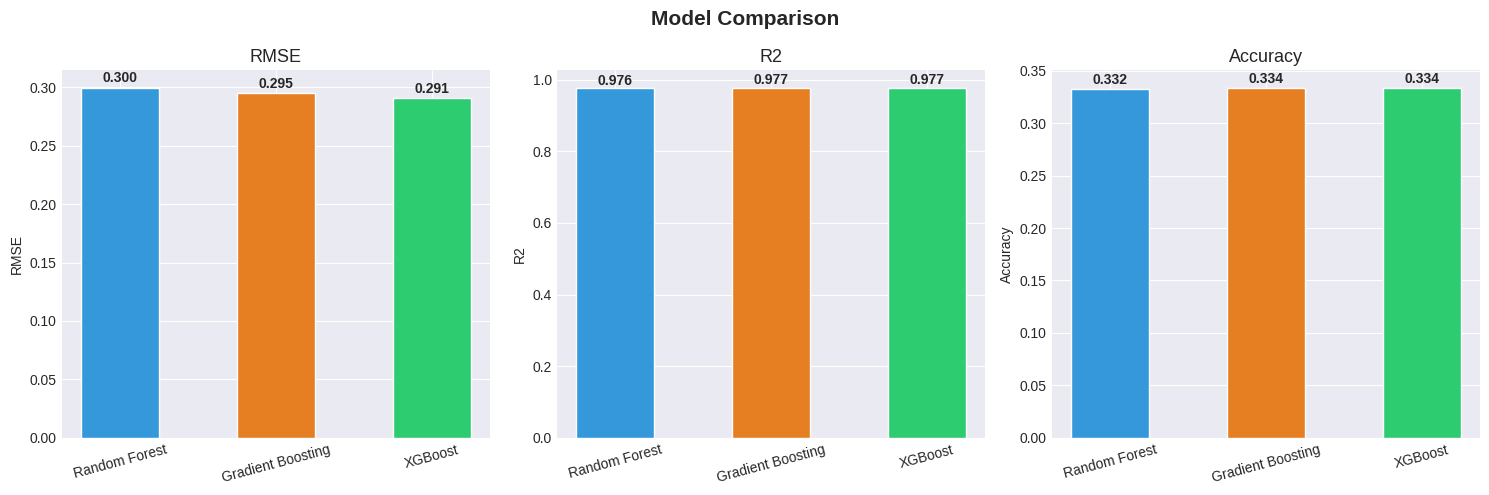

In [21]:
results = pd.DataFrame({
    'Model':    ['Random Forest', 'Gradient Boosting', 'XGBoost'],
    'RMSE':     [rf_rmse,  gb_rmse,  xgb_rmse],
    'R2':       [rf_r2,    gb_r2,    xgb_r2],
    'Accuracy': [rf_acc,   gb_acc,   xgb_acc]
})
print(results.round(4).to_string(index=False))

colors = ['#3498db', '#e67e22', '#2ecc71']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison', fontsize=15, fontweight='bold')

for ax, metric in zip(axes, ['RMSE', 'R2', 'Accuracy']):
    bars = ax.bar(results['Model'], results[metric], color=colors, edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=13)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

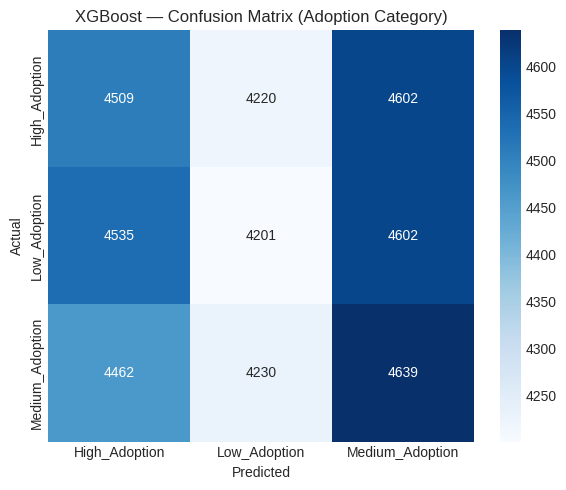


                 precision    recall  f1-score   support

  High_Adoption       0.33      0.34      0.34     13331
   Low_Adoption       0.33      0.31      0.32     13338
Medium_Adoption       0.34      0.35      0.34     13331

       accuracy                           0.33     40000
      macro avg       0.33      0.33      0.33     40000
   weighted avg       0.33      0.33      0.33     40000



In [22]:
# Confusion matrix for best model (XGBoost classifier)
cm = confusion_matrix(y_test_clf, y_pred_xgb_clf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=adoption_labels, yticklabels=adoption_labels)
plt.title('XGBoost — Confusion Matrix (Adoption Category)')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

print()
print(classification_report(y_test_clf, y_pred_xgb_clf, target_names=adoption_labels))

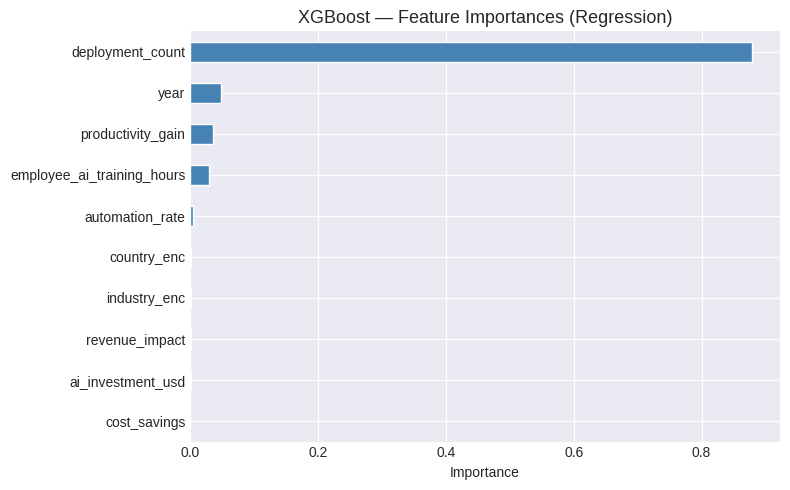

In [23]:
# Feature importance from XGBoost regressor
fi = pd.Series(xgb_reg.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(8, 5))
fi.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('XGBoost — Feature Importances (Regression)', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

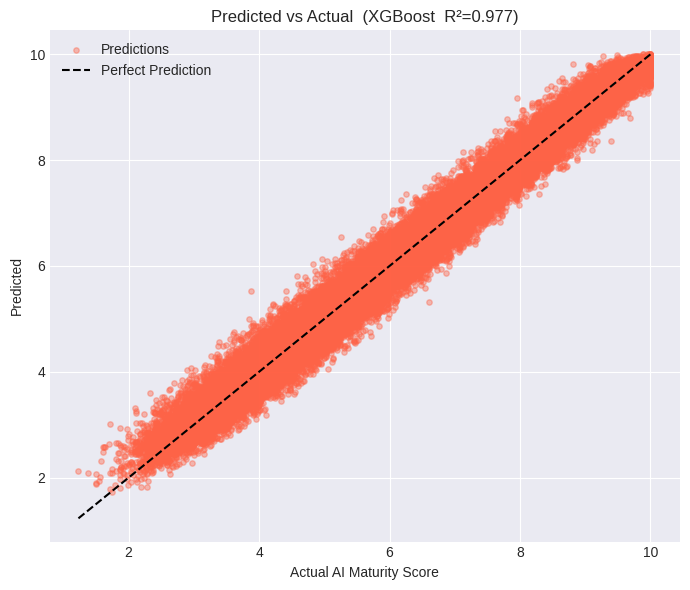

In [24]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test_reg, y_pred_xgb_reg, alpha=0.4, s=15, color='tomato', label='Predictions')
lims = [min(y_test_reg.min(), y_pred_xgb_reg.min()),
        max(y_test_reg.max(), y_pred_xgb_reg.max())]
plt.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect Prediction')
plt.xlabel('Actual AI Maturity Score'); plt.ylabel('Predicted')
plt.title(f'Predicted vs Actual  (XGBoost  R²={xgb_r2:.3f})')
plt.legend(); plt.tight_layout()
plt.savefig('pred_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()

/tmp/ipykernel_4034/1172455814.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test[:200], plot_type='bar', show=False)


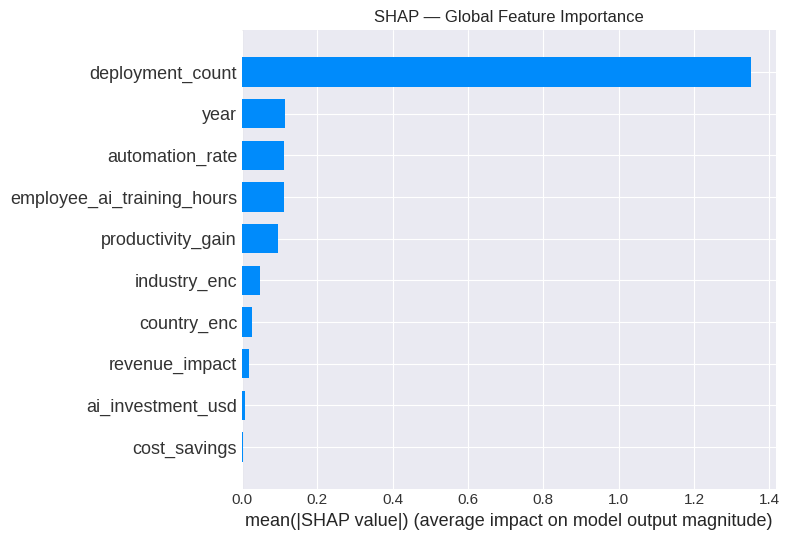

In [25]:
explainer = shap.Explainer(xgb_reg, X_train)
shap_values = explainer(X_test[:200])

# ── Summary bar plot (global importance) ─────────────────────────────────
plt.figure()
shap.summary_plot(shap_values, X_test[:200], plot_type='bar', show=False)
plt.title('SHAP — Global Feature Importance')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()

/tmp/ipykernel_4034/147510185.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test[:200], show=False)


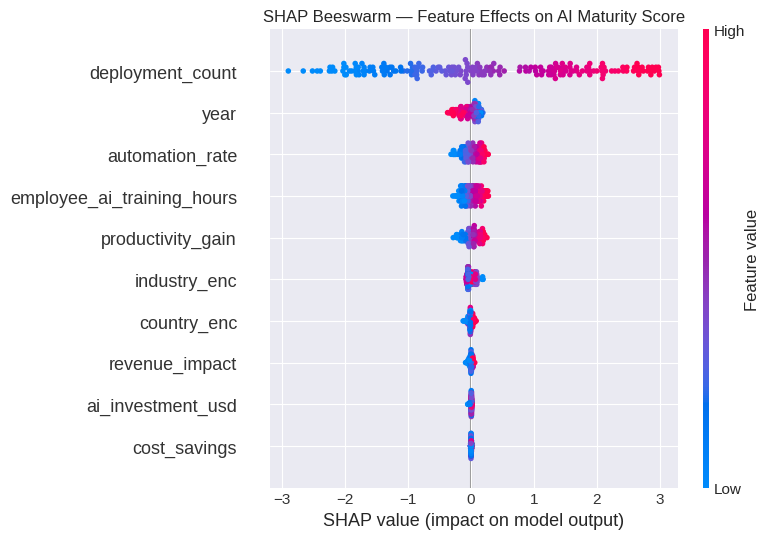

In [26]:
plt.figure()
shap.summary_plot(shap_values, X_test[:200], show=False)
plt.title('SHAP Beeswarm — Feature Effects on AI Maturity Score')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

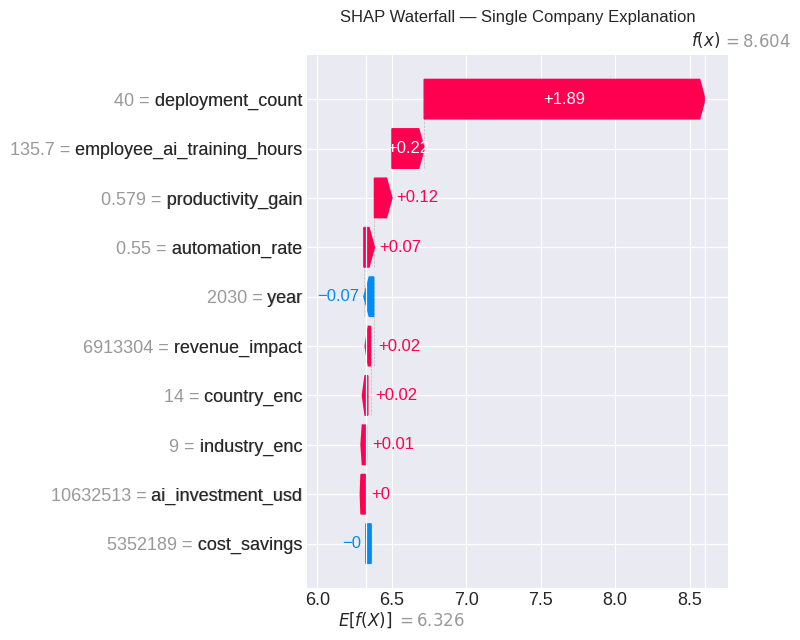

In [27]:
shap.plots.waterfall(shap_values[0], show=False)
plt.title('SHAP Waterfall — Single Company Explanation')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=120, bbox_inches='tight')
plt.show()

In [28]:
N_SIMULATIONS = 500
noise_level   = 0.05   # 5% random noise on each feature

mc_predictions = []

for i in range(N_SIMULATIONS):
    # Add small random noise to simulate input uncertainty
    noise = np.random.normal(loc=0, scale=noise_level, size=X_test.shape)
    X_noisy = X_test.values + noise * X_test.values.std(axis=0)
    preds = xgb_reg.predict(X_noisy)
    mc_predictions.append(preds)

mc_predictions = np.array(mc_predictions)   # shape (500, n_test_samples)

# Stats across simulations
mc_mean = mc_predictions.mean(axis=0)
mc_std  = mc_predictions.std(axis=0)
mc_p05  = np.percentile(mc_predictions, 5, axis=0)
mc_p95  = np.percentile(mc_predictions, 95, axis=0)

print(f"Mean prediction:  {mc_mean.mean():.3f}")
print(f"Avg uncertainty (std): {mc_std.mean():.3f}")
print(f"90% CI width:     {(mc_p95 - mc_p05).mean():.3f}")

Mean prediction:  6.221
Avg uncertainty (std): 0.118
90% CI width:     0.353


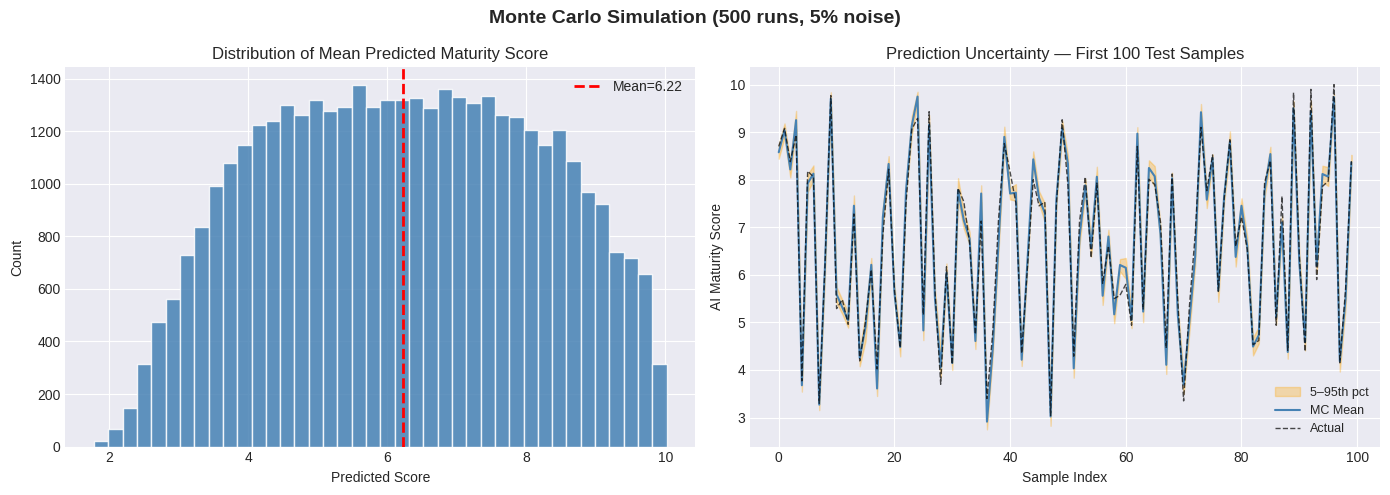

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Monte Carlo Simulation (500 runs, 5% noise)', fontsize=14, fontweight='bold')

# Left: distribution of mean predictions
axes[0].hist(mc_mean, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(mc_mean.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={mc_mean.mean():.2f}')
axes[0].set_title('Distribution of Mean Predicted Maturity Score')
axes[0].set_xlabel('Predicted Score'); axes[0].set_ylabel('Count')
axes[0].legend()

# Right: uncertainty (std) per test sample (first 100)
sample_idx = np.arange(100)
axes[1].fill_between(sample_idx, mc_p05[:100], mc_p95[:100], alpha=0.3, color='orange', label='5–95th pct')
axes[1].plot(sample_idx, mc_mean[:100], color='steelblue', linewidth=1.5, label='MC Mean')
axes[1].plot(sample_idx, y_test_reg.values[:100], 'k--', linewidth=1, alpha=0.7, label='Actual')
axes[1].set_title('Prediction Uncertainty — First 100 Test Samples')
axes[1].set_xlabel('Sample Index'); axes[1].set_ylabel('AI Maturity Score')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('monte_carlo.png', dpi=120, bbox_inches='tight')
plt.show()

In [30]:
inside = ((y_test_reg.values >= mc_p05) & (y_test_reg.values <= mc_p95)).mean()
print(f"Coverage: {inside*100:.1f}% of actual values fall inside the 90% MC confidence interval")
print("(Good model: ~90%. Lower means the model is overconfident, higher means intervals are too wide)")

Coverage: 43.7% of actual values fall inside the 90% MC confidence interval
(Good model: ~90%. Lower means the model is overconfident, higher means intervals are too wide)


In [31]:
artifacts = {
    'xgb_regressor':   xgb_reg,
    'xgb_classifier':  xgb_clf,
    'rf_regressor':    rf_reg,
    'gb_regressor':    gb_reg,
    'label_encoders':  le_dict,
    'feature_cols':    feature_cols,
    'adoption_labels': adoption_labels.tolist(),
}

with open('corporate_adoption_models.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

size_mb = os.path.getsize('corporate_adoption_models.pkl') / 1e6
print(f"✅ Models saved to corporate_adoption_models.pkl  ({size_mb:.1f} MB)")

✅ Models saved to corporate_adoption_models.pkl  (140.2 MB)
